# WGCNA Module × DEG Overlap 분석
- WGCNA eigengene hierarchical clustering → 2 clusters
- DEG_80 overlap 결과 (Hepatitis/Cirrhosis × Up/Down) 와 교차 확인

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = '/data1/project/yeonu/065_multi_rna'
WGCNA_DIR = os.path.join(BASE_DIR, 'WGCNA_80/results_output')
DEG_DIR = os.path.join(BASE_DIR, 'Deg_80/results_output/overlap_genes')

CELLTYPE_MAP = {
    'Hepatocytes': 'Hepatocyte',
    'T_Cells': 'Tcell',
    'Mesenchymal': 'Mesenchymal',
    'Macrophages': 'Macrophage',
    'NK_Cells': 'NKcell',
    'Endothelial_Cells': 'Endothelial',
    'Plasma_Cells': 'Plasmacell',
    'DCs': 'DC',
    'B_Cells': 'Bcell',
}

def load_deg_genes(deg_name, condition, direction):
    prefix = f'overlap_{deg_name}_{condition}_{direction}_'
    for f in os.listdir(DEG_DIR):
        if f.startswith(prefix) and f.endswith('.txt'):
            with open(os.path.join(DEG_DIR, f)) as fh:
                return set(line.strip() for line in fh if line.strip())
    return set()

def analyze_celltype(ct, deg_name):
    # WGCNA 로드
    p_path = os.path.join(WGCNA_DIR, ct, f'{ct}_Network.p')
    with open(p_path, 'rb') as f:
        pywgcna = pickle.load(f)
    MEs = pywgcna.datME
    gene_info = pd.read_csv(os.path.join(WGCNA_DIR, ct, 'hub_genes', 'all_genes_wgcna_info.csv'), index_col=0)
    
    module_colors = [col.replace('ME', '') for col in MEs.columns]
    
    # Eigengene clustering
    dist = pdist(MEs.T, metric='correlation')
    Z = linkage(dist, method='average')
    labels = fcluster(Z, t=2, criterion='maxclust')
    
    c1_colors = [module_colors[i] for i in range(len(module_colors)) if labels[i] == 1]
    c2_colors = [module_colors[i] for i in range(len(module_colors)) if labels[i] == 2]
    
    genes_c1 = set(gene_info[gene_info['moduleColors'].isin(c1_colors)].index)
    genes_c2 = set(gene_info[gene_info['moduleColors'].isin(c2_colors)].index)
    
    # DEG 로드
    hep_up = load_deg_genes(deg_name, 'Hepatitis_only', 'Up')
    cir_up = load_deg_genes(deg_name, 'Cirrhosis_only', 'Up')
    hep_down = load_deg_genes(deg_name, 'Hepatitis_only', 'Down')
    cir_down = load_deg_genes(deg_name, 'Cirrhosis_only', 'Down')
    
    return {
        'MEs': MEs, 'Z': Z, 'module_colors': module_colors,
        'c1_colors': c1_colors, 'c2_colors': c2_colors,
        'genes_c1': genes_c1, 'genes_c2': genes_c2,
        'hep_up': hep_up, 'cir_up': cir_up,
        'hep_down': hep_down, 'cir_down': cir_down,
    }

def show_result(ct, r):
    # DEG 총 개수 표
    deg_table = pd.DataFrame({
        'Hepatitis': [len(r['hep_up']), len(r['hep_down'])],
        'Cirrhosis': [len(r['cir_up']), len(r['cir_down'])],
    }, index=['Up(TC)', 'Down(NT)'])
    
    print(f'--- DEG_80 결과 ---')
    display(deg_table)
    print()
    
    # Dendrogram
    fig, ax = plt.subplots(figsize=(8, 3))
    dendrogram(r['Z'], labels=r['module_colors'], ax=ax, leaf_font_size=10)
    ax.set_title(f'{ct} — Eigengene Dendrogram', fontweight='bold')
    ax.set_ylabel('Correlation distance')
    plt.tight_layout()
    plt.show()
    
    # Module overlap 테이블
    rows = []
    for label, colors, genes in [('Module1', r['c1_colors'], r['genes_c1']),
                                  ('Module2', r['c2_colors'], r['genes_c2'])]:
        rows.append({
            'Cluster': label,
            'Modules': ', '.join(colors),
            'Module Genes': len(genes),
            'case1: Hep Up': len(genes & r['hep_up']),
            'case2: Cirr Up': len(genes & r['cir_up']),
            'case3: Hep Down': len(genes & r['hep_down']),
            'case4: Cirr Down': len(genes & r['cir_down']),
        })
    
    df = pd.DataFrame(rows).set_index('Cluster')
    display(df)
    
    diff = abs(len(r['genes_c1']) - len(r['genes_c2']))
    print(f'Module genes 차이: {diff}')

print('Ready.')

Ready.


---
## 1. Hepatocytes

--- DEG_80 결과 ---


,Hepatitis,Cirrhosis
Up(TC),76,223
Down(NT),110,511


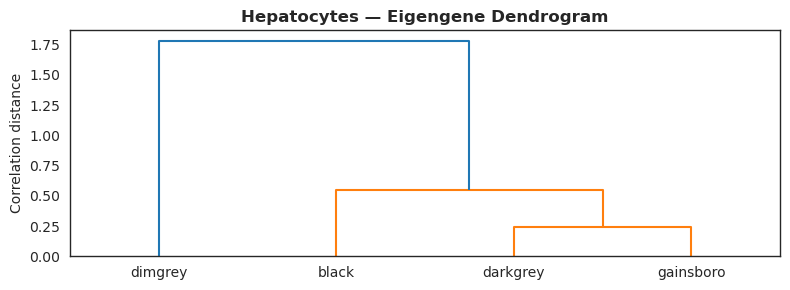

,Modules,Module Genes,case1: Hep Up,case2: Cirr Up,case3: Hep Down,case4: Cirr Down
Cluster,,,,,,
Module1,"black, darkgrey, gainsboro",491,46,201,57,77
Module2,dimgrey,850,30,22,53,434


Module genes 차이: 359


In [2]:
r = analyze_celltype('Hepatocytes', 'Hepatocyte')
show_result('Hepatocytes', r)

---
## 2. T_Cells

--- DEG_80 결과 ---


,Hepatitis,Cirrhosis
Up(TC),101,311
Down(NT),84,324


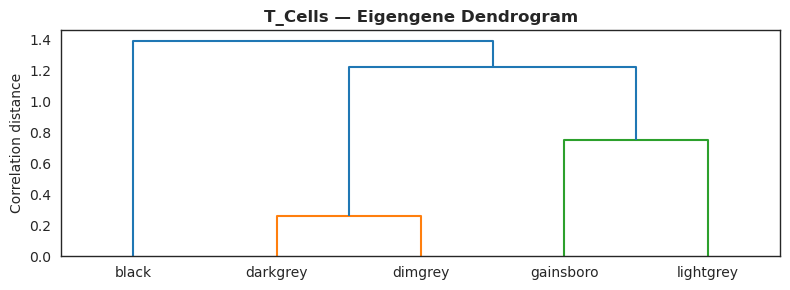

,Modules,Module Genes,case1: Hep Up,case2: Cirr Up,case3: Hep Down,case4: Cirr Down
Cluster,,,,,,
Module1,"darkgrey, dimgrey, gainsboro, lightgrey",1238,95,265,66,313
Module2,black,103,6,46,18,11


Module genes 차이: 1135


In [3]:
r = analyze_celltype('T_Cells', 'Tcell')
show_result('T_Cells', r)

---
## 3. Mesenchymal

--- DEG_80 결과 ---


,Hepatitis,Cirrhosis
Up(TC),426,346
Down(NT),144,391


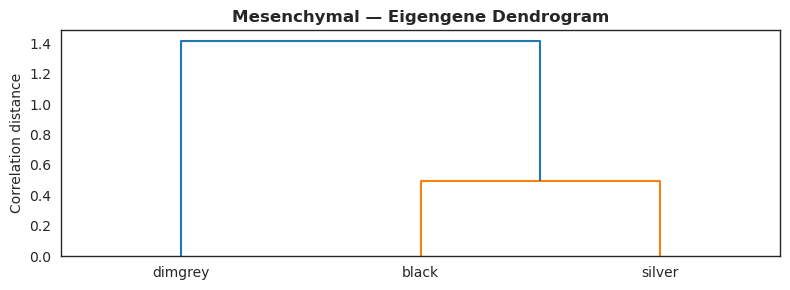

,Modules,Module Genes,case1: Hep Up,case2: Cirr Up,case3: Hep Down,case4: Cirr Down
Cluster,,,,,,
Module1,"black, silver",1289,426,307,101,391
Module2,dimgrey,52,0,39,43,0


Module genes 차이: 1237


In [4]:
r = analyze_celltype('Mesenchymal', 'Mesenchymal')
show_result('Mesenchymal', r)

---
## 4. Macrophages

--- DEG_80 결과 ---


,Hepatitis,Cirrhosis
Up(TC),106,179
Down(NT),112,135


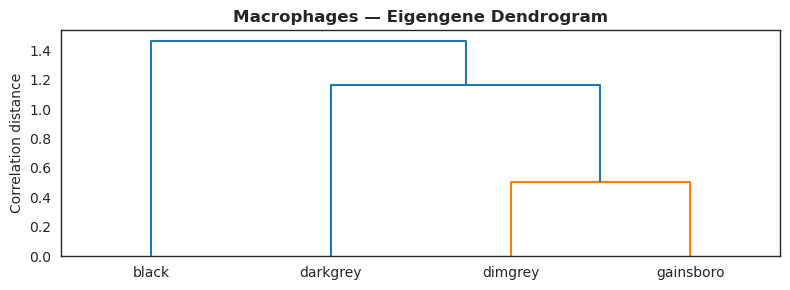

,Modules,Module Genes,case1: Hep Up,case2: Cirr Up,case3: Hep Down,case4: Cirr Down
Cluster,,,,,,
Module1,"darkgrey, dimgrey, gainsboro",1156,99,104,57,133
Module2,black,185,7,75,55,2


Module genes 차이: 971


In [5]:
r = analyze_celltype('Macrophages', 'Macrophage')
show_result('Macrophages', r)

---
## 5. NK_Cells

--- DEG_80 결과 ---


,Hepatitis,Cirrhosis
Up(TC),86,170
Down(NT),88,124


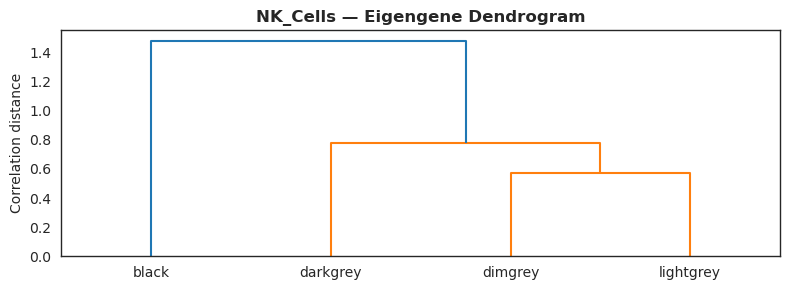

,Modules,Module Genes,case1: Hep Up,case2: Cirr Up,case3: Hep Down,case4: Cirr Down
Cluster,,,,,,
Module1,"darkgrey, dimgrey, lightgrey",1037,81,71,41,116
Module2,black,304,5,99,47,8


Module genes 차이: 733


In [6]:
r = analyze_celltype('NK_Cells', 'NKcell')
show_result('NK_Cells', r)

---
## 6. Endothelial_Cells

--- DEG_80 결과 ---


,Hepatitis,Cirrhosis
Up(TC),1,438
Down(NT),37,523


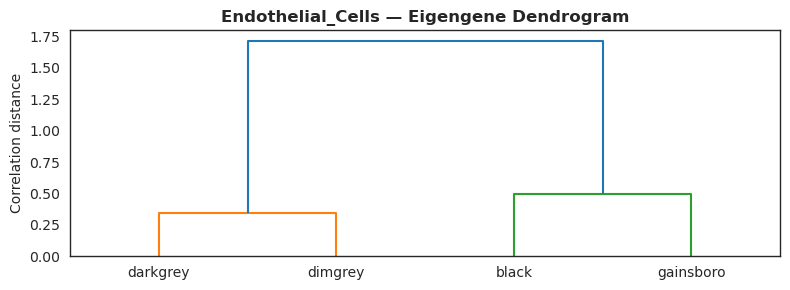

,Modules,Module Genes,case1: Hep Up,case2: Cirr Up,case3: Hep Down,case4: Cirr Down
Cluster,,,,,,
Module1,"darkgrey, dimgrey",790,0,9,7,511
Module2,"black, gainsboro",551,1,429,30,12


Module genes 차이: 239


In [7]:
r = analyze_celltype('Endothelial_Cells', 'Endothelial')
show_result('Endothelial_Cells', r)

---
## 7. Plasma_Cells

--- DEG_80 결과 ---


,Hepatitis,Cirrhosis
Up(TC),34,100
Down(NT),28,19


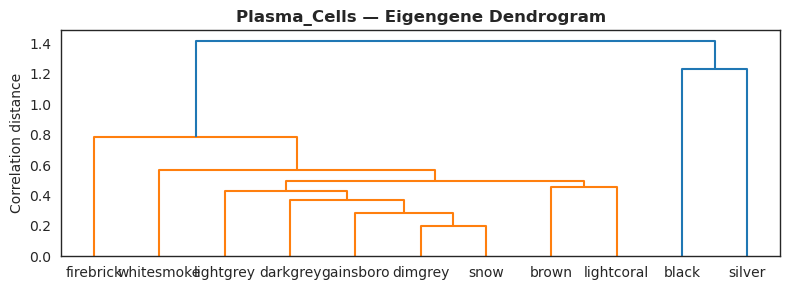

,Modules,Module Genes,case1: Hep Up,case2: Cirr Up,case3: Hep Down,case4: Cirr Down
Cluster,,,,,,
Module1,"brown, darkgrey, dimgrey, firebrick, gainsboro...",1103,29,57,14,18
Module2,"black, silver",238,5,43,14,1


Module genes 차이: 865


In [8]:
r = analyze_celltype('Plasma_Cells', 'Plasmacell')
show_result('Plasma_Cells', r)

---
## 8. DCs

--- DEG_80 결과 ---


,Hepatitis,Cirrhosis
Up(TC),45,52
Down(NT),29,17


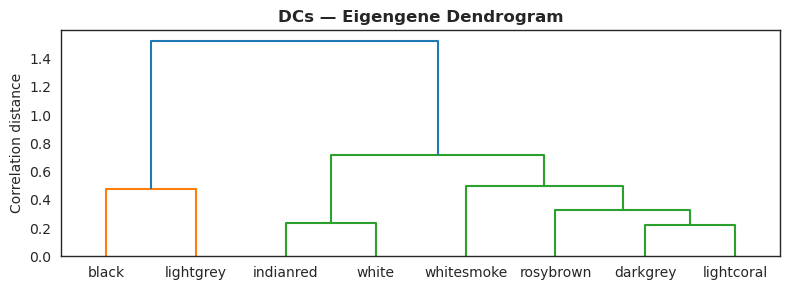

,Modules,Module Genes,case1: Hep Up,case2: Cirr Up,case3: Hep Down,case4: Cirr Down
Cluster,,,,,,
Module1,"black, lightgrey",277,9,34,27,1
Module2,"darkgrey, indianred, lightcoral, rosybrown, wh...",1064,36,18,2,16


Module genes 차이: 787


In [9]:
r = analyze_celltype('DCs', 'DC')
show_result('DCs', r)

---
## 9. B_Cells

--- DEG_80 결과 ---


,Hepatitis,Cirrhosis
Up(TC),13,32
Down(NT),0,3


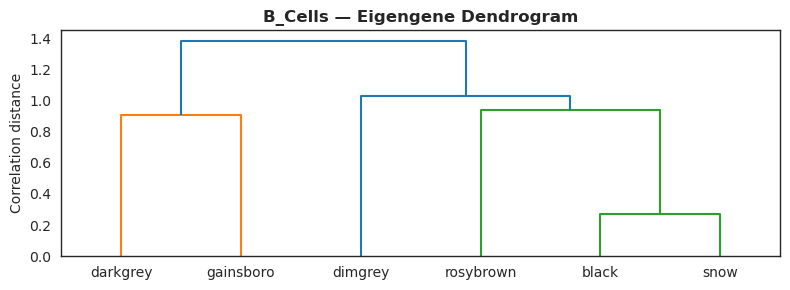

,Modules,Module Genes,case1: Hep Up,case2: Cirr Up,case3: Hep Down,case4: Cirr Down
Cluster,,,,,,
Module1,"darkgrey, gainsboro",364,0,16,0,0
Module2,"black, dimgrey, rosybrown, snow",976,13,15,0,3


Module genes 차이: 612


In [10]:
r = analyze_celltype('B_Cells', 'Bcell')
show_result('B_Cells', r)

---
## 전체 요약

In [11]:
summary = []
for ct, deg_name in CELLTYPE_MAP.items():
    r = analyze_celltype(ct, deg_name)
    for label, colors, genes in [('Module1', r['c1_colors'], r['genes_c1']),
                                  ('Module2', r['c2_colors'], r['genes_c2'])]:
        summary.append({
            'Cell Type': ct,
            'Cluster': label,
            'Modules': ', '.join(colors),
            'Module Genes': len(genes),
            'case1: Hep Up': len(genes & r['hep_up']),
            'case2: Cirr Up': len(genes & r['cir_up']),
            'case3: Hep Down': len(genes & r['hep_down']),
            'case4: Cirr Down': len(genes & r['cir_down']),
        })

df_summary = pd.DataFrame(summary)
display(df_summary)

,Cell Type,Cluster,Modules,Module Genes,case1: Hep Up,case2: Cirr Up,case3: Hep Down,case4: Cirr Down
0,Hepatocytes,Module1,"black, darkgrey, gainsboro",491,46,201,57,77
1,Hepatocytes,Module2,dimgrey,850,30,22,53,434
2,T_Cells,Module1,"darkgrey, dimgrey, gainsboro, lightgrey",1238,95,265,66,313
3,T_Cells,Module2,black,103,6,46,18,11
4,Mesenchymal,Module1,"black, silver",1289,426,307,101,391
5,Mesenchymal,Module2,dimgrey,52,0,39,43,0
6,Macrophages,Module1,"darkgrey, dimgrey, gainsboro",1156,99,104,57,133
7,Macrophages,Module2,black,185,7,75,55,2
8,NK_Cells,Module1,"darkgrey, dimgrey, lightgrey",1037,81,71,41,116
9,NK_Cells,Module2,black,304,5,99,47,8
